# Trabajo Final de Machine Learning - Ejercicio 3
## Clustering: perfiles de clientes mayoristas

**Grupo:** F
**Integrantes:**
- Alexis Gonzalez
- Luis Morales
- Alexia Orce
- Georgina Sicco
- Emiliano Prockoff

Se comparan K-Means y DBSCAN para identificar perfiles de clientes a partir de sus gastos anuales por categoria.

## 1. Metadata y planteamiento

El dataset Wholesale Customers contiene 440 clientes, con canal, region y gasto anual en Fresh, Milk, Grocery, Frozen, Detergents_Paper y Delicassen. Para clustering se excluyen `Channel` y `Region`, porque el objetivo es descubrir perfiles basados en comportamiento de compra, no reproducir etiquetas administrativas.

Pregunta: **es posible distinguir grupos de clientes con patrones de gasto diferentes?**

## Contexto del rubro: distribucion mayorista

La distribución mayorista conecta proveedores con comercios, restaurantes, hoteles y otros clientes profesionales. Estos clientes pueden comprar grandes volúmenes de productos de distintas categorías, y sus necesidades de reposición no son todas iguales.

El dataset resume el gasto anual de cada cliente en productos frescos, lácteos, almacén, congelados, detergentes y papel, y delicatessen. También informa el canal de compra y la región, que sirven para describir el negocio pero no se utilizan para construir los grupos.

Conocer perfiles de compra puede ayudar a organizar visitas comerciales, definir surtidos, planificar inventario y diseñar promociones más relevantes. Por ejemplo, un cliente especializado en productos frescos puede requerir una estrategia distinta de otro con alto gasto en almacén y detergentes.

El clustering busca descubrir esos perfiles sin una etiqueta previa. Los grupos encontrados deben interpretarse con criterio comercial y validarse con la experiencia del negocio; un segmento matemáticamente bien separado no siempre es automáticamente una categoría útil para tomar decisiones.

In [ ]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score

sns.set_theme(style='whitegrid', palette='deep')
RANDOM_STATE = 42

In [7]:
DATA_PATH = Path('datasets/Wholesale_customers_data.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'No se encontro el dataset: {DATA_PATH.resolve()}')

df = pd.read_csv(DATA_PATH)
print(f'Dimensiones: {df.shape}')
display(df.head())
display(df.describe().T)

Dimensiones: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.322727,0.468052,1.0,1.00,1.0,2.00,2.0
Region,440.0,2.543182,0.774272,1.0,2.00,3.0,3.00,3.0
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


Valores faltantes: 0


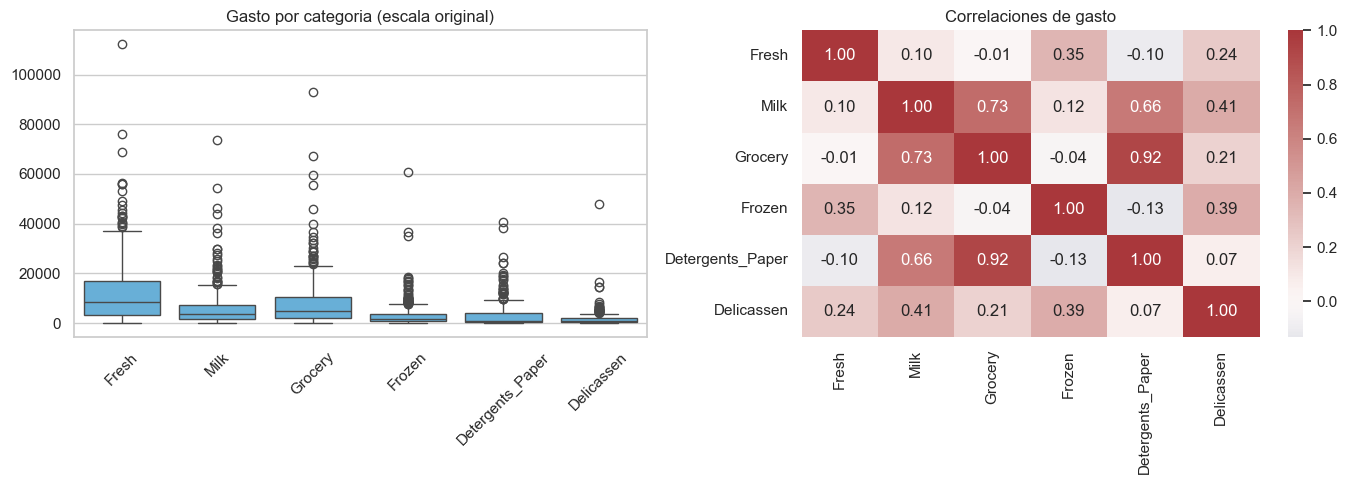

In [3]:
spending_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
print('Valores faltantes:', df[spending_cols].isna().sum().sum())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df[spending_cols], ax=axes[0], color='#56b4e9')
axes[0].set_title('Gasto por categoria (escala original)')
axes[0].tick_params(axis='x', rotation=45)
sns.heatmap(df[spending_cols].corr(), cmap='vlag', center=0, annot=True, fmt='.2f', ax=axes[1])
axes[1].set_title('Correlaciones de gasto')
plt.tight_layout()
plt.show()

# La transformacion log reduce el peso de valores extremos sin eliminar clientes.
X_log = np.log1p(df[spending_cols])
X_scaled = StandardScaler().fit_transform(X_log)

## 2. Analisis de las variables utilizadas para clustering

Las variables utilizadas para agrupar son los gastos anuales en seis categorias: Fresh, Milk, Grocery, Frozen, Detergents_Paper y Delicassen. No se utilizan `Channel` ni `Region` para que los grupos reflejen el comportamiento de compra.

- Los histogramas muestran la distribucion de cada categoria.
- Los diagramas de dispersion permiten observar pares de categorias que podrían moverse juntas.
- Los perfiles relativos ayudan a distinguir clientes especializados de clientes con compras diversificadas.

Este paso es importante porque los valores extremos y las diferencias de escala pueden afectar fuertemente la distancia entre clientes.

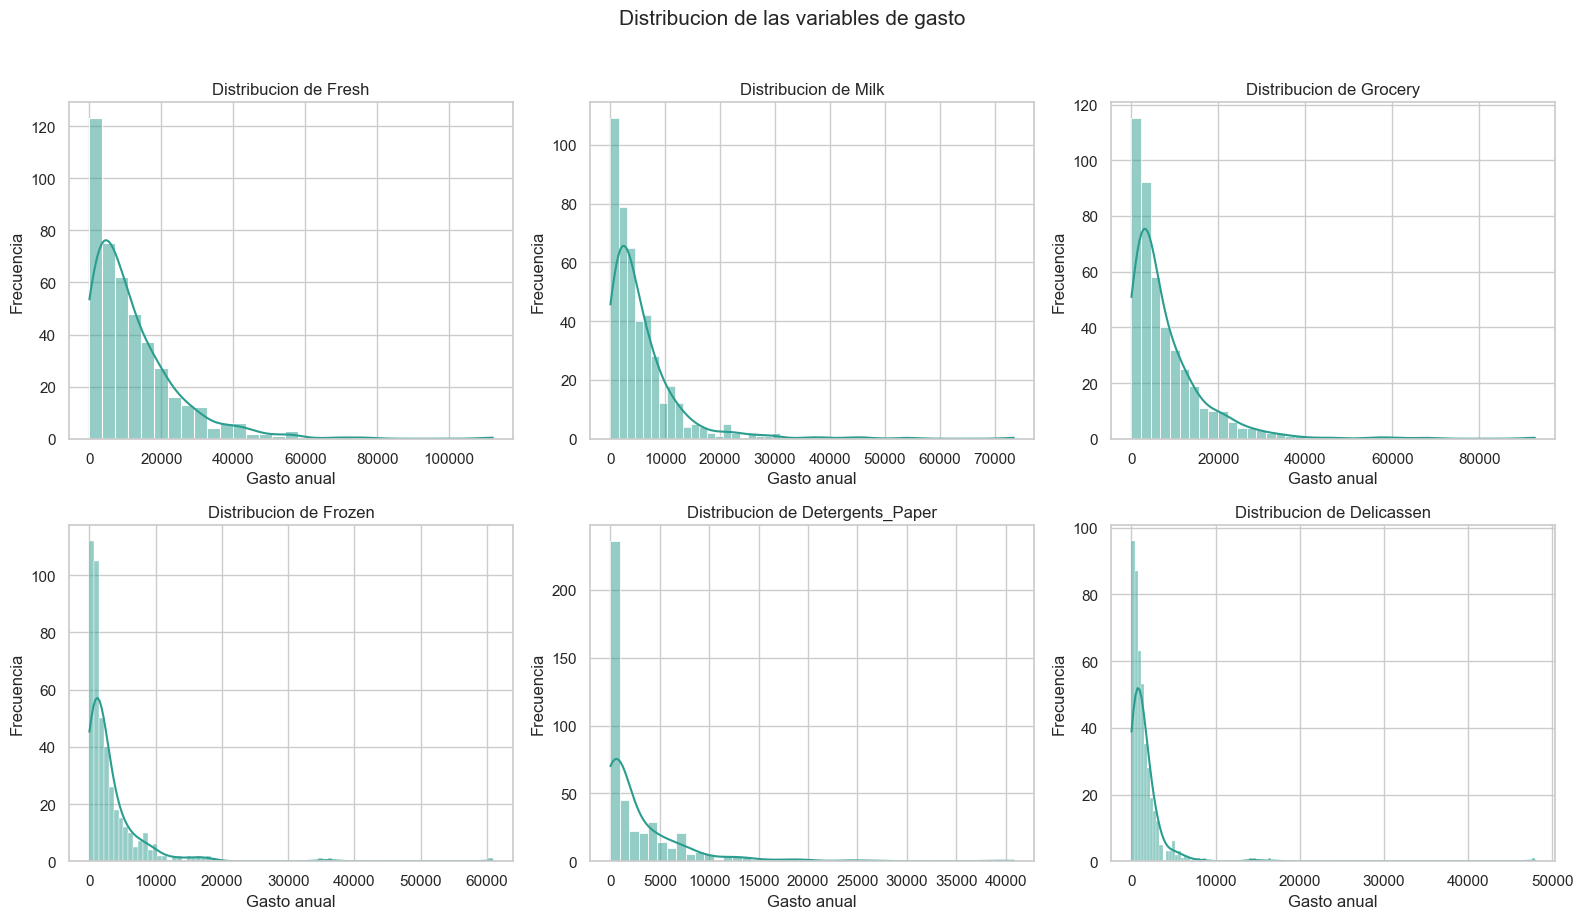

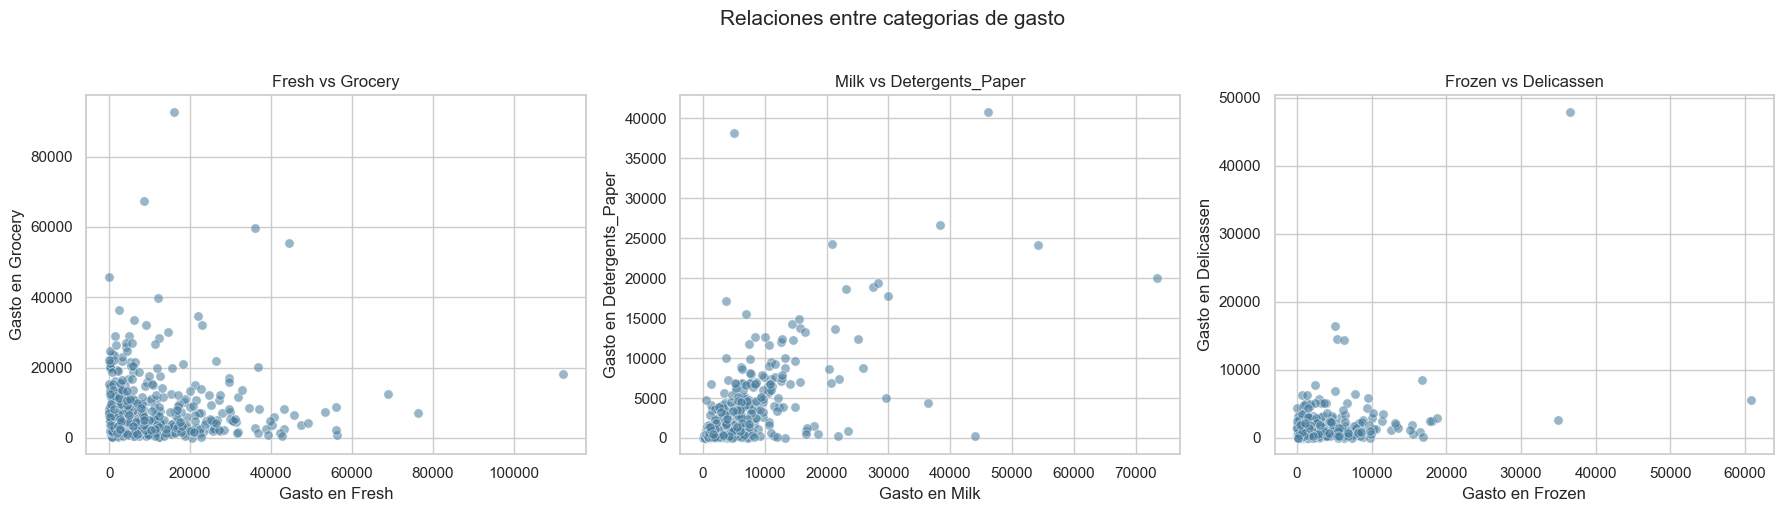

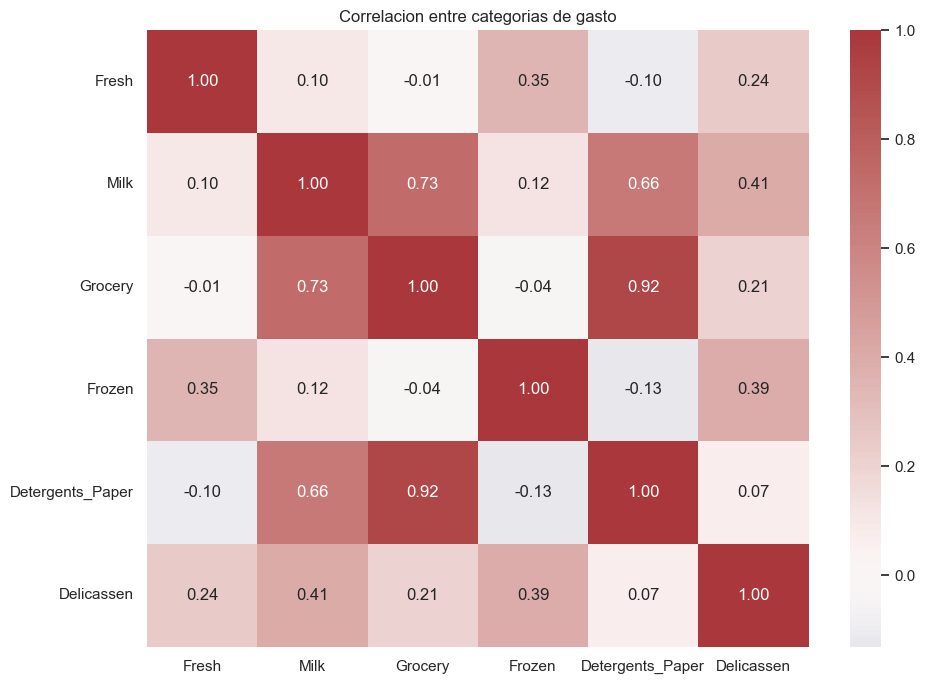

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, column in zip(axes.ravel(), spending_cols):
    sns.histplot(data=df, x=column, kde=True, ax=ax, color='#2a9d8f')
    ax.set_title(f'Distribucion de {column}')
    ax.set_xlabel('Gasto anual')
    ax.set_ylabel('Frecuencia')
plt.suptitle('Distribucion de las variables de gasto', y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
spending_pairs = [('Fresh', 'Grocery'), ('Milk', 'Detergents_Paper'), ('Frozen', 'Delicassen')]
for ax, (x_column, y_column) in zip(axes, spending_pairs):
    sns.scatterplot(data=df, x=x_column, y=y_column, alpha=0.55, s=45, ax=ax, color='#457b9d')
    ax.set_title(f'{x_column} vs {y_column}')
    ax.set_xlabel(f'Gasto en {x_column}')
    ax.set_ylabel(f'Gasto en {y_column}')
plt.suptitle('Relaciones entre categorias de gasto', y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(df[spending_cols].corr(), annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Correlacion entre categorias de gasto')
plt.tight_layout()
plt.show()

## 2.1. EDA profundo: estructura de clientes y valores extremos

Profundizamos en la composición del gasto total, la asimetría de cada categoría, los clientes con consumo nulo o muy elevado y las relaciones entre categorías. Este diagnóstico justifica la transformación logarítmica y la estandarización usadas antes de agrupar.

Registros duplicados: 0


,faltantes,unicos,asimetria,mediana,maximo
Fresh,0,433,2.56,8504.0,112151
Milk,0,421,4.05,3627.0,73498
Grocery,0,430,3.59,4755.5,92780
Frozen,0,426,5.91,1526.0,60869
Detergents_Paper,0,417,3.63,816.5,40827
Delicassen,0,403,11.15,965.5,47943


Clientes sin gasto en ninguna categoria: 0


,total_spending,active_categories
count,440.00,440.0
mean,33226.14,6.0
std,26356.30,0.0
min,904.00,6.0
25%,17448.75,6.0
50%,27492.00,6.0
75%,41307.50,6.0
max,199891.00,6.0


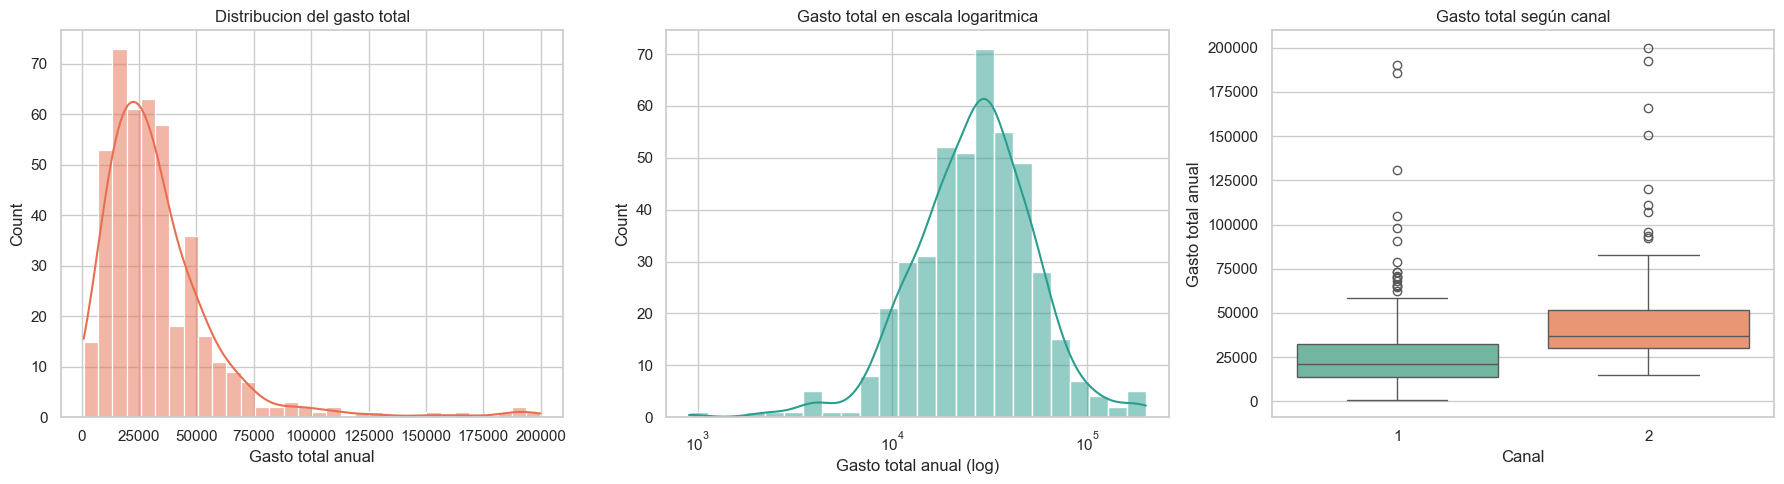

,0.01,0.25,0.50,0.75,0.99
Fresh,28.0,3128.0,8504.0,16934.0,56083.0
Milk,256.0,1533.0,3627.0,7190.0,37610.0
Grocery,260.0,2153.0,4756.0,10656.0,43436.0
Frozen,44.0,742.0,1526.0,3554.0,17965.0
Detergents_Paper,9.0,257.0,816.0,3922.0,22572.0
Delicassen,7.0,408.0,966.0,1820.0,8275.0


,participacion_promedio
Fresh,37.50%
Grocery,22.97%
Milk,16.75%
Frozen,10.58%
Detergents_Paper,7.42%
Delicassen,4.78%


In [11]:
df['total_spending'] = df[spending_cols].sum(axis=1)
df['active_categories'] = (df[spending_cols] > 0).sum(axis=1)

quality_summary = pd.DataFrame({
    'faltantes': df[spending_cols].isna().sum(),
    'unicos': df[spending_cols].nunique(),
    'asimetria': df[spending_cols].skew(),
    'mediana': df[spending_cols].median(),
    'maximo': df[spending_cols].max()
})
print('Registros duplicados:', df.duplicated().sum())
display(quality_summary.round(2))
print('Clientes sin gasto en ninguna categoria:', (df['total_spending'] == 0).sum())
display(df[['total_spending', 'active_categories']].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(data=df, x='total_spending', kde=True, ax=axes[0], color='#e76f51')
axes[0].set_title('Distribucion del gasto total')
axes[0].set_xlabel('Gasto total anual')
sns.histplot(data=df, x='total_spending', kde=True, log_scale=True, ax=axes[1], color='#2a9d8f')
axes[1].set_title('Gasto total en escala logaritmica')
axes[1].set_xlabel('Gasto total anual (log)')
sns.boxplot(data=df, x='Channel', y='total_spending', hue='Channel', legend=False, ax=axes[2], palette='Set2')
axes[2].set_title('Gasto total según canal')
axes[2].set_xlabel('Canal')
axes[2].set_ylabel('Gasto total anual')
plt.tight_layout()
plt.show()

spending_quantiles = df[spending_cols].quantile([0.01, 0.25, 0.50, 0.75, 0.99]).T.round(0)
display(spending_quantiles)

profile_share = df[spending_cols].div(df[spending_cols].sum(axis=1).replace(0, np.nan), axis=0).mean().sort_values(ascending=False)
display(profile_share.rename('participacion_promedio').to_frame().style.format({'participacion_promedio': '{:.2%}'}))

## 3. K-Means

Se usa `log1p` para reducir la asimetria de los gastos y luego se estandarizan las variables. Se comparan varios valores de K usando silhouette y Davies-Bouldin.

In [4]:
k_rows = []
for k in range(2, 9):
    labels = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit_predict(X_scaled)
    k_rows.append({'K': k, 'Silhouette': silhouette_score(X_scaled, labels), 'Davies-Bouldin': davies_bouldin_score(X_scaled, labels)})
k_results = pd.DataFrame(k_rows)
display(k_results.style.format({'Silhouette':'{:.3f}', 'Davies-Bouldin':'{:.3f}'}))
best_k = int(k_results.loc[k_results['Silhouette'].idxmax(), 'K'])
kmeans = KMeans(n_clusters=best_k, n_init=30, random_state=RANDOM_STATE)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)
print('K elegido por silhouette:', best_k)

,K,Silhouette,Davies-Bouldin
0,2,0.290,1.352
1,3,0.258,1.348
2,4,0.188,1.541
3,5,0.192,1.484
4,6,0.195,1.414
5,7,0.196,1.392
6,8,0.191,1.385


K elegido por silhouette: 2


## 4. DBSCAN

DBSCAN identifica regiones densas y permite marcar observaciones atipicas como ruido (`-1`). Se prueba una pequeña grilla de hiperparametros y se descartan configuraciones con un unico grupo valido.

In [5]:
db_rows = []
for eps in [0.7, 0.9, 1.1, 1.3, 1.5]:
    for min_samples in [4, 6, 10]:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
        valid = labels != -1
        groups = set(labels[valid])
        if valid.sum() > 1 and len(groups) >= 2:
            db_rows.append({'eps': eps, 'min_samples': min_samples, 'grupos': len(groups), 'ruido_%': 100 * (~valid).mean(), 'Silhouette_sin_ruido': silhouette_score(X_scaled[valid], labels[valid])})
db_results = pd.DataFrame(db_rows).sort_values('Silhouette_sin_ruido', ascending=False)
display(db_results.head(10).style.format({'ruido_%':'{:.1f}', 'Silhouette_sin_ruido':'{:.3f}'}))
if db_results.empty:
    raise ValueError('La grilla de DBSCAN no produjo al menos dos grupos validos.')
best_db = db_results.iloc[0]
dbscan = DBSCAN(eps=float(best_db['eps']), min_samples=int(best_db['min_samples']))
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)
print('DBSCAN seleccionado:', dict(best_db))

,eps,min_samples,grupos,ruido_%,Silhouette_sin_ruido
4,0.900000,10,2,56.4,0.461
6,1.100000,10,2,27.7,0.261
1,0.700000,6,5,83.0,0.245
5,1.100000,4,2,18.6,0.154
0,0.700000,4,13,66.4,0.106
3,0.900000,6,4,39.8,0.024
2,0.900000,4,4,34.3,-0.136


DBSCAN seleccionado: {'eps': np.float64(0.9), 'min_samples': np.float64(10.0), 'grupos': np.float64(2.0), 'ruido_%': np.float64(56.36363636363636), 'Silhouette_sin_ruido': np.float64(0.46131726810181645)}


## 5. Resultados obtenidos

Se visualizan los grupos, sus tamaños y sus perfiles de gasto para comparar K-Means y DBSCAN.

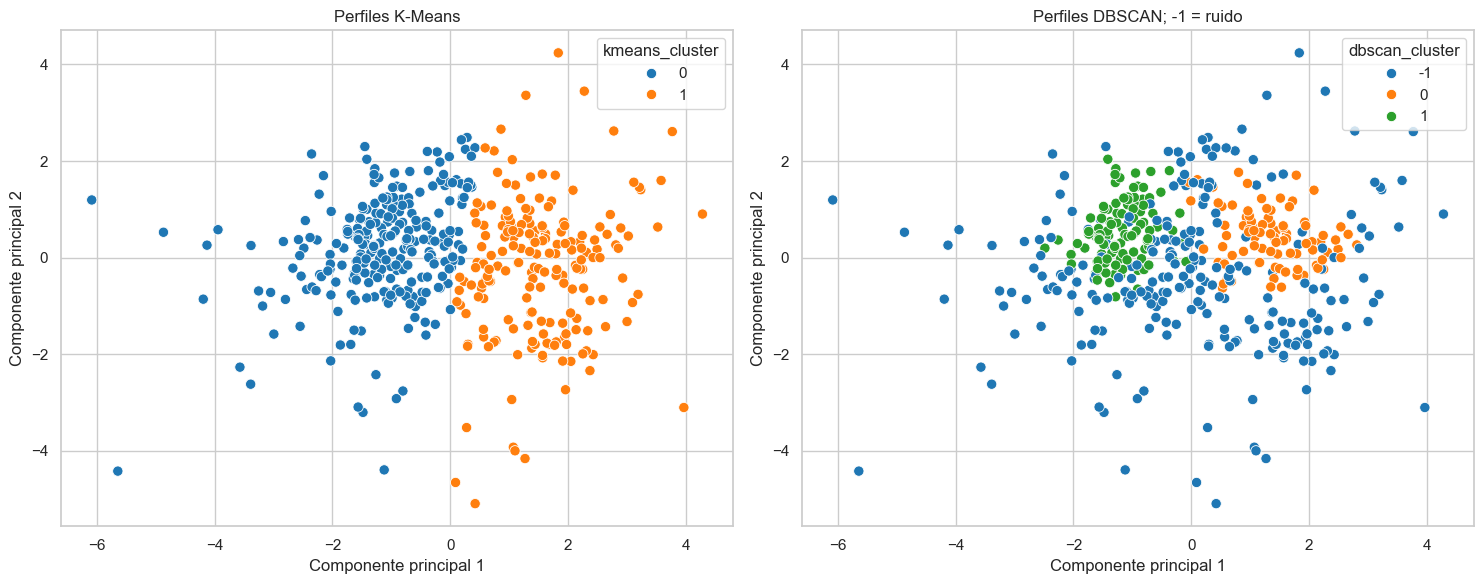

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
kmeans_cluster,,,,,,
0,10348.0,1871.0,2406.0,2225.0,328.0,750.0
1,5406.0,7690.0,11527.0,1062.0,4495.0,1388.0


Cantidad de clientes por cluster K-Means:


,clientes
kmeans_cluster,
0,252
1,188


Cantidad de clientes por cluster DBSCAN:


,clientes
dbscan_cluster,
-1,248
0,88
1,104


In [6]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=df['kmeans_cluster'], palette='tab10', ax=axes[0], s=55)
axes[0].set_title('Perfiles K-Means')
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=df['dbscan_cluster'], palette='tab10', ax=axes[1], s=55)
axes[1].set_title('Perfiles DBSCAN; -1 = ruido')
for ax in axes: ax.set_xlabel('Componente principal 1'); ax.set_ylabel('Componente principal 2')
plt.tight_layout()
plt.show()

profile = df.groupby('kmeans_cluster')[spending_cols].median().round(0)
display(profile)
print('Cantidad de clientes por cluster K-Means:')
display(df['kmeans_cluster'].value_counts().sort_index().rename('clientes').to_frame())
print('Cantidad de clientes por cluster DBSCAN:')
display(df['dbscan_cluster'].value_counts().sort_index().rename('clientes').to_frame())

## Evaluacion grafica: por que no se utiliza ROC

La curva ROC requiere una variable objetivo con clases conocidas, por ejemplo “si” y “no”. En clustering no existe una respuesta objetivo previa: justamente buscamos descubrir los grupos. Por eso una ROC no seria válida. En su lugar, se utiliza la curva de valores silhouette para analizar la calidad y separacion de los grupos encontrados.

## Metricas no aplicables

La precision es una métrica de clasificación y no corresponde a este ejercicio de clustering, porque no existe una clase objetivo conocida. La calidad de los grupos se evalúa con silhouette, Davies-Bouldin, tamaño de los clusters y coherencia de sus perfiles.

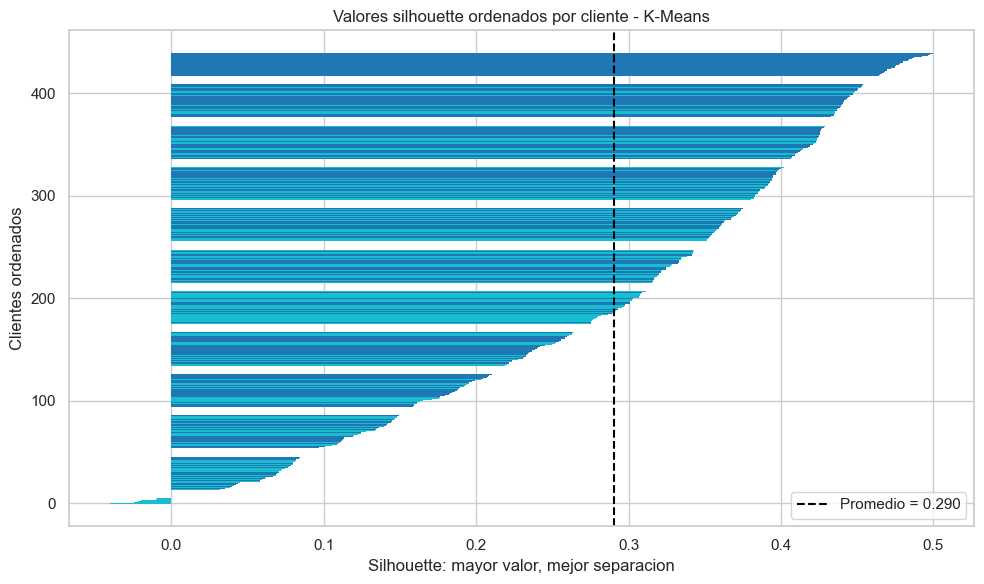

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples

if 'kmeans_cluster' not in df.columns:
    kmeans = KMeans(n_clusters=best_k, n_init=30, random_state=RANDOM_STATE)
    df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

silhouette_values = silhouette_samples(X_scaled, df['kmeans_cluster'])
order = np.argsort(silhouette_values)
colors = plt.cm.tab10(df['kmeans_cluster'].to_numpy()[order] / max(1, best_k - 1))
plt.figure(figsize=(10, 6))
plt.barh(np.arange(len(order)), silhouette_values[order], color=colors, edgecolor='none')
plt.axvline(silhouette_values.mean(), linestyle='--', color='black', label=f'Promedio = {silhouette_values.mean():.3f}')
plt.title('Valores silhouette ordenados por cliente - K-Means')
plt.xlabel('Silhouette: mayor valor, mejor separacion')
plt.ylabel('Clientes ordenados')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Interpretacion de resultados

Los gráficos de perfiles, tamaños de cluster y silhouette permiten evaluar la calidad y utilidad de los agrupamientos.

## 7. Justificacion de la seleccion de algoritmos e interpretacion

### Objetivo del analisis

En este ejercicio no existe una respuesta correcta previamente definida. El algoritmo recibe los gastos de cada cliente y busca clientes con comportamientos parecidos. Por eso los grupos no son “buenos” o “malos”: son perfiles que deben interpretarse con el contexto del negocio.

### Criterio para seleccionar los algoritmos

Se comparan dos estrategias porque responden a preguntas diferentes. K-Means busca grupos compactos y requiere definir cuántos grupos se desean analizar. DBSCAN busca zonas de alta densidad, no obliga a fijar de antemano la cantidad de grupos y puede identificar observaciones atipicas. La comparación permite evaluar si los perfiles encontrados son compactos, separados y útiles para el negocio.

**K-Means.** Primero se elige una cantidad de grupos, K. El algoritmo ubica un centro para cada grupo y asigna cada cliente al centro mas cercano. Luego mueve los centros y repite el proceso hasta que los grupos se estabilizan. Es util para encontrar perfiles relativamente compactos, pero hay que decidir K y cada cliente debe quedar asignado a algun grupo.

**DBSCAN.** No necesita indicar de antemano cuántos grupos existen. Busca zonas donde hay muchos clientes cercanos entre si. Los clientes aislados pueden quedar como ruido, identificados con la etiqueta `-1`. Es valioso para encontrar perfiles irregulares y detectar clientes atipicos, aunque depende bastante de los parametros `eps` y `min_samples`.

### Preparacion y criterios de evaluacion

Los gastos tienen escalas muy distintas y algunos clientes gastan muchisimo mas que el promedio. `log1p` reduce el peso de esas diferencias extremas y la estandarizacion coloca las categorias en escalas comparables. Asi, una categoria no domina el agrupamiento solo porque sus numeros sean mas grandes.

- **Silhouette:** indica si cada cliente esta mas cerca de su propio grupo que de los otros. Valores mayores suelen indicar grupos mejor separados.
- **Davies-Bouldin:** compara la dispersion interna de los grupos con la distancia entre ellos. Valores menores suelen ser mejores.
- **Cantidad de clientes por grupo:** ayuda a saber si un perfil es relevante o si solo contiene unos pocos casos.
- **Perfil por medianas:** resume el gasto tipico de cada grupo y permite ponerle un nombre comprensible, como “clientes orientados a productos frescos” o “clientes con alto gasto en grocery y detergentes”.

La proyeccion PCA del grafico reduce seis categorias a dos ejes para poder visualizar los datos. Es una ayuda visual: que dos puntos se vean cerca en el grafico no significa necesariamente que sean iguales en todas las dimensiones originales.

**Decision final:** un segmento es util cuando es interpretable, tiene suficiente cantidad de clientes, presenta una buena separacion y se mantiene razonablemente estable. Antes de tomar decisiones comerciales conviene validarlo con expertos del negocio y con datos de otros periodos.